# RFM Analysis

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
OR_df = pd.read_csv("D:\Elevvo\Tasks\Task 3\online_retail.csv")

In [3]:
df = OR_df.copy()

In [4]:
df.shape

(1067371, 8)

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


## Data Cleaning

#### Check for missing values

In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Description and Customer ID have null values

In [9]:
(df['Customer ID'].isnull().sum() / len(df)) * 100

22.766872999172733

Customer ID is essential for segmentation, so rows missing Customer ID will be dropped

In [10]:
df = df.dropna(subset= ['Customer ID'])  # drop null values of customer id column

In [11]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

#### Removing Duplicates

In [12]:
df.duplicated().sum()

26479

In [13]:
df.drop_duplicates(inplace= True)

In [14]:
df.duplicated().sum()

0

In [15]:
df.shape

(797885, 8)

#### Fix columns' data types

In [16]:
# changing data type of column InvoiceDate to datetime, and Customer ID to string
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['Customer ID'].astype('Int64').astype('str')

In [17]:
# Drop the original 'Customer ID' column
df.drop(columns=['Customer ID'], inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 797885 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      797885 non-null  object        
 1   StockCode    797885 non-null  object        
 2   Description  797885 non-null  object        
 3   Quantity     797885 non-null  int64         
 4   InvoiceDate  797885 non-null  datetime64[ns]
 5   Price        797885 non-null  float64       
 6   Country      797885 non-null  object        
 7   CustomerID   797885 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 54.8+ MB


#### Check negative values

In [19]:
df.describe()

,Quantity,InvoiceDate,Price
count,797885.000000,797885,797885.000000
mean,12.602980,2011-01-02 13:17:34.141160704,3.702732
min,-80995.000000,2009-12-01 07:45:00,0.000000
25%,2.000000,2010-07-02 09:47:00,1.250000
50%,5.000000,2010-12-02 12:33:00,1.950000
75%,12.000000,2011-07-31 15:50:00,3.750000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,191.670371,NaN,71.392549


Quantity have negative values, which indicate return transactions

#### Calculating Revenue Column

In [20]:
df['Revenue'] = df['Quantity'] * df['Price']

In [21]:
df['Revenue'] 

0           83.40
1           81.00
2           81.00
3          100.80
4           30.00
            ...  
1067366     12.60
1067367     16.60
1067368     16.60
1067369     14.85
1067370     18.00
Name: Revenue, Length: 797885, dtype: float64

#### Removing Canceled Orders 

In [22]:
cancelled_rows = df[df['Invoice'].str.lower().str.startswith('c')]

In [23]:
cancelled_rows

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country,CustomerID,Revenue
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,Australia,16321,-35.40
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,Australia,16321,-9.90
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,Australia,16321,-17.00
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,Australia,16321,-12.60
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,Australia,16321,-35.40
...,...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,United Kingdom,14397,-9.13
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,United Kingdom,15498,-224.69
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,United Kingdom,15311,-54.75
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,United Kingdom,17315,-1.25


In [24]:
# remove canceled transactions
df = df[~df['Invoice'].str.lower().str.startswith('c')]

In [25]:
df[df['Invoice'].str.lower().str.startswith('c')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country,CustomerID,Revenue


In [26]:
df.shape

(779495, 9)

In [27]:
# check if there still negative Quantity 
df.describe()

,Quantity,InvoiceDate,Price,Revenue
count,779495.000000,779495,779495.000000,779495.000000
mean,13.507085,2011-01-03 01:46:36.061116416,3.218199,22.289821
min,1.000000,2009-12-01 07:45:00,0.000000,0.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,4.950000
50%,6.000000,2010-12-02 14:09:00,1.950000,12.480000
75%,12.000000,2011-08-01 13:48:00,3.750000,19.800000
max,80995.000000,2011-12-09 12:50:00,10953.500000,168469.600000
std,146.540284,NaN,29.674823,227.416962


In [28]:
df[df['Quantity'] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country,CustomerID,Revenue


In [29]:
df.nunique()

Invoice        36975
StockCode       4631
Description     5283
Quantity         438
InvoiceDate    34591
Price            666
Country           41
CustomerID      5881
Revenue         3920
dtype: int64

There are more product descriptions than stock codes, indicating that some products have multiple descriptions

In [30]:
# StockCode with multiple Description 

desc_per_code = df.groupby('StockCode')['Description'].nunique()
inconsistent_codes = desc_per_code[desc_per_code > 1]

print(len(inconsistent_codes))

624


In [32]:
# Create a helper column for description length
df['desc_len'] = df['Description'].str.len()

# For each StockCode, pick the longest description
longest_desc = df.loc[df.groupby('StockCode')['desc_len'].idxmax()]

# Create a mapping dictionary
stock_desc_map = longest_desc.set_index('StockCode')['Description'].to_dict()

In [33]:
df['Description'] = df['StockCode'].map(stock_desc_map)

# Drop helper column
df = df.drop(columns='desc_len')

In [37]:
# Check that every StockCode has exactly one Description
df.groupby('StockCode')['Description'].nunique().max()




1

In [61]:
# removing records with price = 0 from data
df = df[df['Price'] > 0]


### EDA

In [62]:
total_revenue = df['Revenue'].sum()
total_revenue

17374804.268000003

In [63]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64

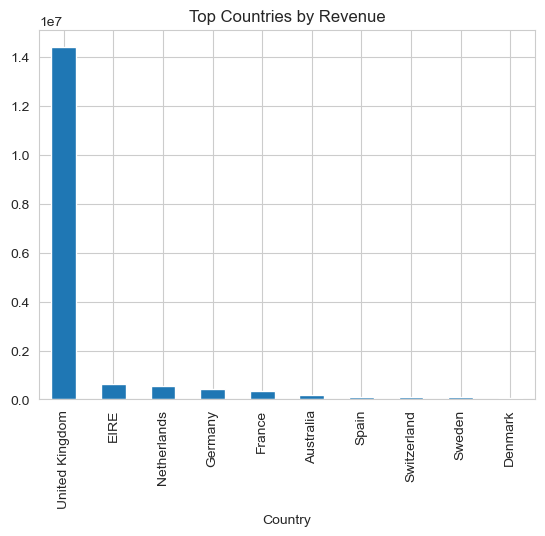

In [64]:
country_sales.head(10).plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.show()

The United Kingdom dominates the sales, indicating the retailer primarily operates in this market.

### Monthly Sales Trend

In [65]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Revenue'].sum()

C:\Users\pc\AppData\Local\Temp\ipykernel_24360\2273720390.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['InvoiceDate'].dt.to_period('M')


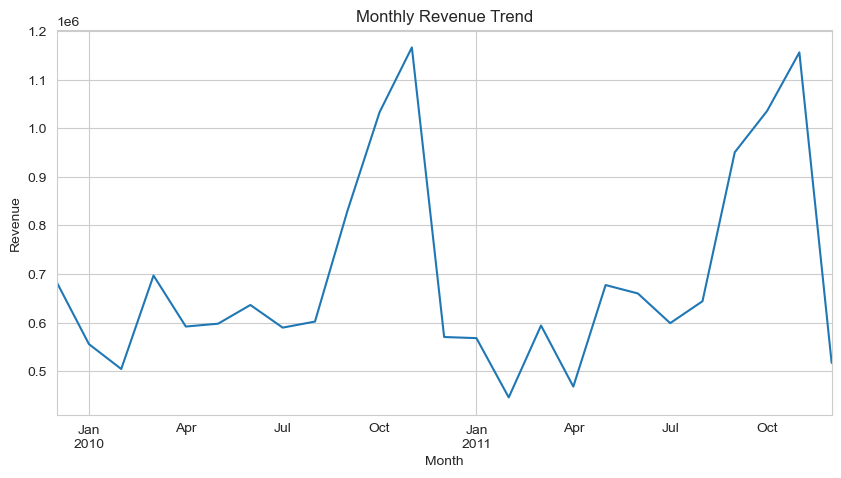

In [67]:
monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

Sales tend to increase during holiday seasons, especially near the end of the year.

In [68]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [69]:
# calculate RFM metrics
rfm = df.groupby('CustomerID').agg({

    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,

    'Invoice': 'nunique',

    'Revenue': 'sum'

})

In [70]:
rfm.columns = ['Recency','Frequency','Monetary']

In [71]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,12,77556.46
12347,2,8,4921.53
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


#### Recency Distribution

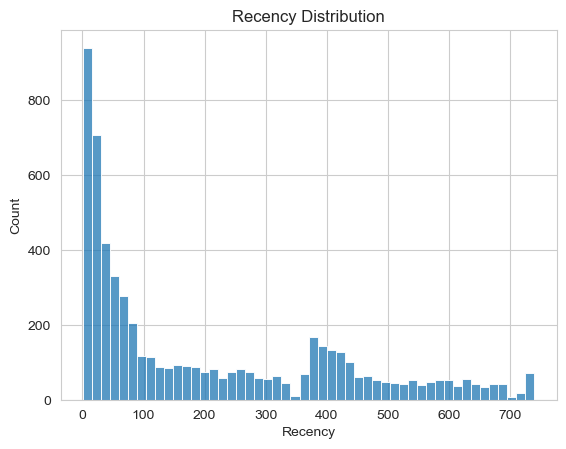

In [72]:
sns.histplot(rfm['Recency'], bins=50)

plt.title("Recency Distribution")
plt.show()

#### Frequency Distribution 

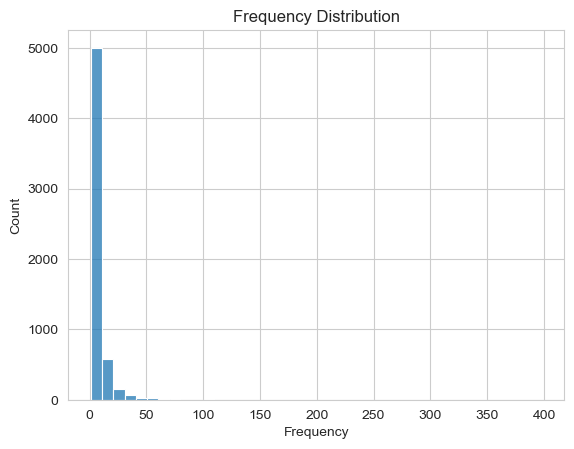

In [73]:
sns.histplot(rfm['Frequency'], bins=40)

plt.title("Frequency Distribution")
plt.show()

In [74]:
#### Monetry Distribution

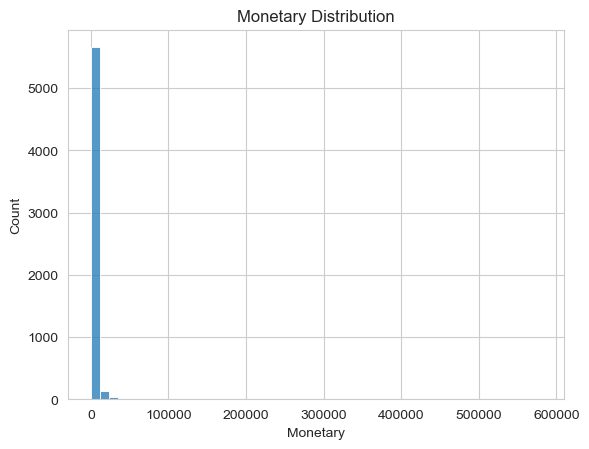

In [75]:
sns.histplot(rfm['Monetary'], bins=50)

plt.title("Monetary Distribution")
plt.show()

### Calculate RFM Scores

In [76]:
# Recency Score
rfm['R'] = pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])

# Frequency Score
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])

# Monetry Score
rfm['M'] = pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])

In [79]:
# Create RFM Score
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

In [80]:
rfm['RFM_Score'].head()

CustomerID
12346    255
12347    545
12348    344
12349    535
12350    212
Name: RFM_Score, dtype: object

### Customer Segmentation

In [81]:
def segment_customer(row):

    if row['R'] >= 4 and row['F'] >= 4:
        return "Champions"

    elif row['F'] >= 4:
        return "Loyal Customers"

    elif row['R'] >= 4:
        return "Potential Loyalists"

    elif row['R'] <= 2 and row['F'] >= 3:
        return "At Risk"

    else:
        return "Lost Customers"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [82]:
rfm['Segment'].value_counts()

Segment
Lost Customers         2174
Champions              1482
Potential Loyalists     882
Loyal Customers         869
At Risk                 471
Name: count, dtype: int64

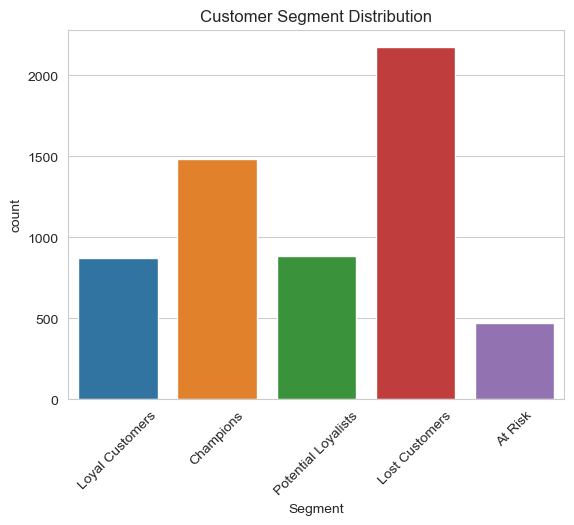

In [83]:
sns.countplot(data=rfm, x='Segment')

plt.title("Customer Segment Distribution")

plt.xticks(rotation=45)

plt.show()

### Revenue Contribution by Segment

In [84]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

segment_revenue

Segment
Champions              1.202433e+07
Loyal Customers        2.782623e+06
Lost Customers         1.197576e+06
Potential Loyalists    8.715857e+05
At Risk                4.986900e+05
Name: Monetary, dtype: float64

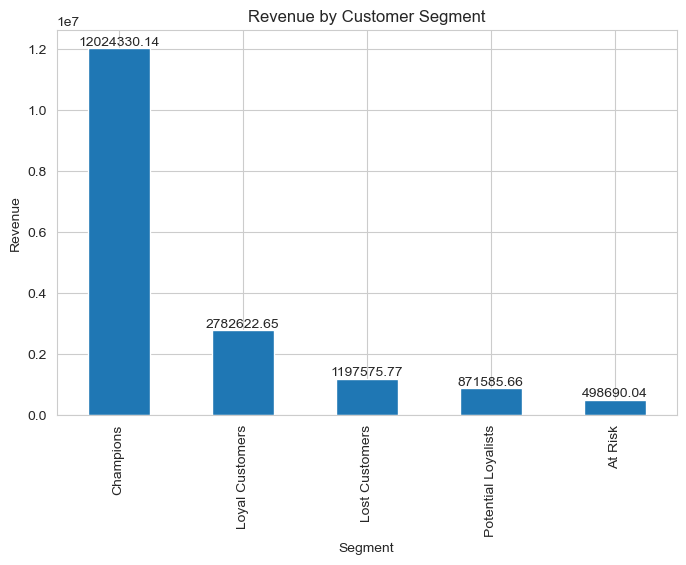

In [ ]:
ax = segment_revenue.plot(kind='bar', figsize=(8,5))
plt.title("Revenue by Customer Segment")
plt.ylabel("Revenue")

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.show()

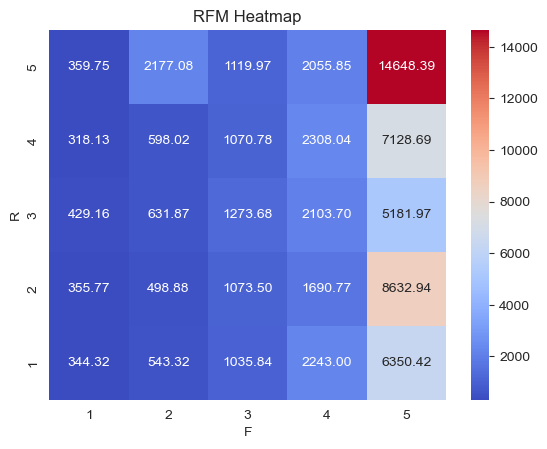

In [89]:
pivot = rfm.pivot_table(

index='R',
columns='F',
values='Monetary',
aggfunc='mean'

)

sns.heatmap(pivot, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("RFM Heatmap")
plt.show()